# Stage 1B.2: Structured Internal Transformation and the Concentration Regime

Stage 1B.2 investigates whether nonlinear oscillator dynamics, evolved over topologies learned from image populations, produce **structured internal transformations**. Unlike earlier stages that focused on static features or infinitesimal responses, Stage 1B.2 uses finite-amplitude perturbations along baseline trajectories to determine if the resulting state changes are reproducible and input-sensitive. This notebook walks through a key discovery from this stage: the **concentration regime**, where energy from a local perturbation relocates onto specific, deterministic destination nodes rather than spreading broadly across the network.


In [1]:
import pickle
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kruskal

# Setup imports from local directory
THIS_DIR = Path(".").resolve()
sys.path.insert(0, str(THIS_DIR))

from bonsai.data.mnist_loader import load_mnist
from bonsai.dynamics.learned_topology_construction import build_class_topology
from stage1b2_core import get_degree_stratified_nodes

# Paths to cached results
RESULTS_DIR = THIS_DIR / "results"
RESULTS_PATH = RESULTS_DIR / "stage1b2_results.pkl"
FINAL_ANALYSIS_PATH = RESULTS_DIR / "stage1b2_final_analysis.pkl"
CONSTRUCTIONS_PATH = RESULTS_DIR / "class0_constructions.pkl"
KMNIST_DIR = THIS_DIR / "../../datasets/kmnist"

# Constants for mapping factor levels to ranks
AMPLITUDE_RANK = {0.025: 1, 0.2: 2, 0.8: 3}
TP_RANK = {0: 1, 0.833: 2, 1.667: 3, 2.5: 4}

print("Environment initialized and paths set.")


Environment initialized and paths set.


## 1. Data Loading and Concentration Metrics

We start by loading the 432 trials from Stage 1B.2. For each trial, we compute measures of energy concentration:
- **top1**: The fraction of energy held by the single largest node.
- **effective_n**: The inverse participation ratio ($1 / \sum q_i^2$), representing the "effective number" of participating nodes. Smaller values indicate higher concentration.


In [2]:
def load_and_process_results():
    with open(RESULTS_PATH, "rb") as f:
        results = pickle.load(f)
    
    with open(CONSTRUCTIONS_PATH, "rb") as f:
        constructions = pickle.load(f)[0]
    W = constructions["constructions"]["T"]
    node_lookup = get_degree_stratified_nodes(W)

    rows = []
    for (t_p, replica, node_label, sign, amplitude), trial in results.items():
        q = np.asarray(trial["fixed_time_q"])
        sorted_q = np.sort(q)[::-1]
        top1 = float(sorted_q[0])
        ipr = float(np.sum(q ** 2))
        effective_n = 1.0 / ipr
        argmax_node = int(np.argmax(q))
        stimulated_node = node_lookup[node_label]
        
        rows.append({
            "t_p": t_p, "replica": replica, "node_label": node_label, "sign": sign,
            "amplitude": amplitude, "top1": top1, "effective_n": effective_n,
            "argmax_node": argmax_node, "stimulated_node": stimulated_node,
            "argmax_is_source": argmax_node == stimulated_node,
        })
    return pd.DataFrame(rows), node_lookup

df, node_lookup = load_and_process_results()
print(f"Loaded {len(df)} trials.")
df.head()


Loaded 432 trials.


,t_p,replica,node_label,sign,amplitude,top1,effective_n,argmax_node,stimulated_node,argmax_is_source
0,0.0,0,low,-1,0.025,0.343941,5.719084,17,17,True
1,0.0,0,low,-1,0.800,0.414967,4.430247,17,17,True
2,0.0,0,low,1,0.200,0.334793,5.914191,17,17,True
3,0.0,0,median,1,0.200,0.090465,20.258169,363,363,True
4,0.0,0,low,1,0.800,0.319286,6.276596,17,17,True


## 2. Amplitude and Sign: A Null Result for Concentration

We first check if the magnitude of the perturbation (amplitude) or its direction (sign) drives the energy concentration. Using Spearman rank correlations and Kruskal-Wallis tests, we find that these factors have little to no systematic effect on the overall concentration level across the full dataset.


In [3]:
# Factor rank mapping
df['amp_rank'] = df['amplitude'].map(AMPLITUDE_RANK)
df['tp_rank'] = df['t_p'].map(TP_RANK)

print("-- Spearman rank correlations --")
for factor in ["amplitude", "t_p"]:
    rank_col = "amp_rank" if factor == "amplitude" else "tp_rank"
    rho, p = spearmanr(df[rank_col], df["top1"])
    print(f"  {factor} vs top1: rho={rho:+.3f}, p={p:.5f}")

print("\n-- Kruskal-Wallis tests --")
for factor in ["amplitude", "sign"]:
    groups = [group["top1"].values for name, group in df.groupby(factor)]
    stat, p = kruskal(*groups)
    print(f"  top1 across {factor} levels: H={stat:.3f}, p={p:.5f}")


-- Spearman rank correlations --
  amplitude vs top1: rho=-0.019, p=0.69608
  t_p vs top1: rho=-0.236, p=0.00000

-- Kruskal-Wallis tests --
  top1 across amplitude levels: H=0.154, p=0.92574
  top1 across sign levels: H=0.007, p=0.93428


## 3. The $t_p \times$ Node Interaction

While amplitude and sign show no global effect, energy concentration is highly sensitive to **when** the perturbation occurs ($t_p$) and **which node** is stimulated. The table below shows the fraction of "highly concentrated" trials (top1 > 0.5) for each $t_p \times$ amplitude cell. Note the striking concentration at $t_p=0$ for certain amplitudes, which we will investigate further.


In [10]:
print('-- Fraction of trials with top1 > 0.5 (highly concentrated) by (t_p, amplitude) --')
ctab = df.groupby(['t_p', 'amplitude'])['top1'].apply(lambda x: (x > 0.5).mean()).unstack()
ctab.columns = [f'amp={a}' for a in ctab.columns]
ctab.index = [f't_p={t}' for t in ctab.index]
display(ctab)

print()
print('CAUTION: this table pools all three stimulated-node types (low/median/high degree)')
print('together at each (t_p, amplitude) cell. It genuinely understates the effect -- e.g.')
print('the 0.333 at (t_p=0, amp=0.025) is 12 concentrated trials out of 36 in that cell, but')
print('those 12 are ALL 12 high-degree-node trials (both signs x 6 replicas = 12/12), while')
print('the low- and median-degree nodes contribute 0 concentrated trials out of the other 24.')
print('Section 4 isolates the high-degree node specifically and shows the true, sharp pattern:')
print('not a modest ~33% rate, but a clean, deterministic split within that one node/time cell.')

-- Fraction of trials with top1 > 0.5 (highly concentrated) by (t_p, amplitude) --


,amp=0.025,amp=0.2,amp=0.8
t_p=0.0,0.333333,0.166667,0.166667
t_p=0.833,0.000000,0.000000,0.000000
t_p=1.667,0.000000,0.000000,0.000000
t_p=2.5,0.000000,0.000000,0.000000



CAUTION: this table pools all three stimulated-node types (low/median/high degree)
together at each (t_p, amplitude) cell. It genuinely understates the effect -- e.g.
the 0.333 at (t_p=0, amp=0.025) is 12 concentrated trials out of 36 in that cell, but
those 12 are ALL 12 high-degree-node trials (both signs x 6 replicas = 12/12), while
the low- and median-degree nodes contribute 0 concentrated trials out of the other 24.
Section 4 isolates the high-degree node specifically and shows the true, sharp pattern:
not a modest ~33% rate, but a clean, deterministic split within that one node/time cell.


## 4. The 4-of-6 Deterministic Breakdown

Focusing on the high-degree node at $t_p=0$, we discover a precise, deterministic pattern. Concentration (top1 > 0.5) occurs in 4 out of the 6 (sign, amplitude) conditions, and in those cases, it is **perfectly uniform** across all 6 replicas. In these trials, the energy relocates from the source node to one of two specific destination nodes (indices 103 or 152).


In [11]:
cell_mask = (df['t_p'] == 0) & (df['node_label'] == 'high')
cell_df = df[cell_mask].copy()
stim_node = node_lookup['high']

print(f"High-degree stimulated node index: {stim_node}")
print(f"Dominant node is ever the stimulated node itself: {cell_df['argmax_is_source'].any()}")

summary = []
for (sign, amp), group in cell_df.groupby(['sign', 'amplitude']):
    dests = set(group['argmax_node'])
    n_conc = (group['top1'] > 0.5).sum()
    summary.append({
        'sign': sign, 'amplitude': amp, 'destinations': dests,
        'concentrated': f"{n_conc}/6",
        'top1_range': f"[{group['top1'].min():.3f}, {group['top1'].max():.3f}]"
    })

pd.DataFrame(summary)


High-degree stimulated node index: 129
Dominant node is ever the stimulated node itself: False


,sign,amplitude,destinations,concentrated,top1_range
0,-1,0.025,{103},6/6,"[0.616, 0.670]"
1,-1,0.200,{103},0/6,"[0.387, 0.446]"
2,-1,0.800,{152},0/6,"[0.181, 0.188]"
3,1,0.025,{103},6/6,"[0.671, 0.720]"
4,1,0.200,{103},6/6,"[0.818, 0.851]"
5,1,0.800,{103},6/6,"[0.976, 0.976]"


## 5. Visualizing the Concentration: Sign $\times$ Amplitude Grid

This grid shows which combinations of sign and amplitude result in a concentrated response for the high-degree node at $t_p=0$. The pattern is perfectly binary (4 concentrated, 2 not).


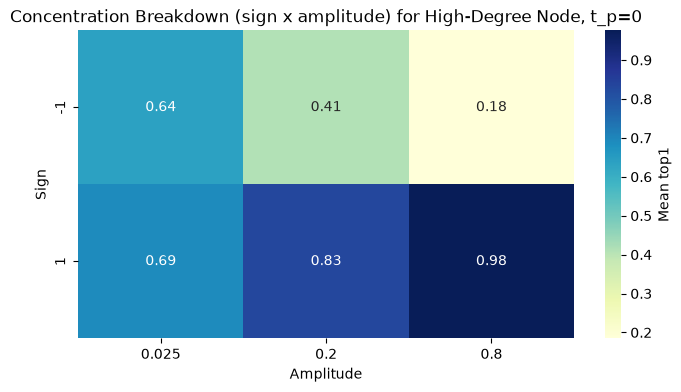

In [12]:
grid_data = cell_df.groupby(['sign', 'amplitude'])['top1'].mean().unstack()
plt.figure(figsize=(8, 4))
sns.heatmap(grid_data, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Mean top1'})
plt.title("Concentration Breakdown (sign x amplitude) for High-Degree Node, t_p=0")
plt.ylabel("Sign")
plt.xlabel("Amplitude")
plt.show()


## 6. Topology Visualization: The Routing Grid

To understand where the energy is going, we visualize the KMNIST class-0 active pixel grid. We mark the high-degree source node and the two destination nodes (103, 152) at their actual positions in the 28x28 grid.


Verified: rebuilt T matches cached T (max abs diff = 2.22e-16)


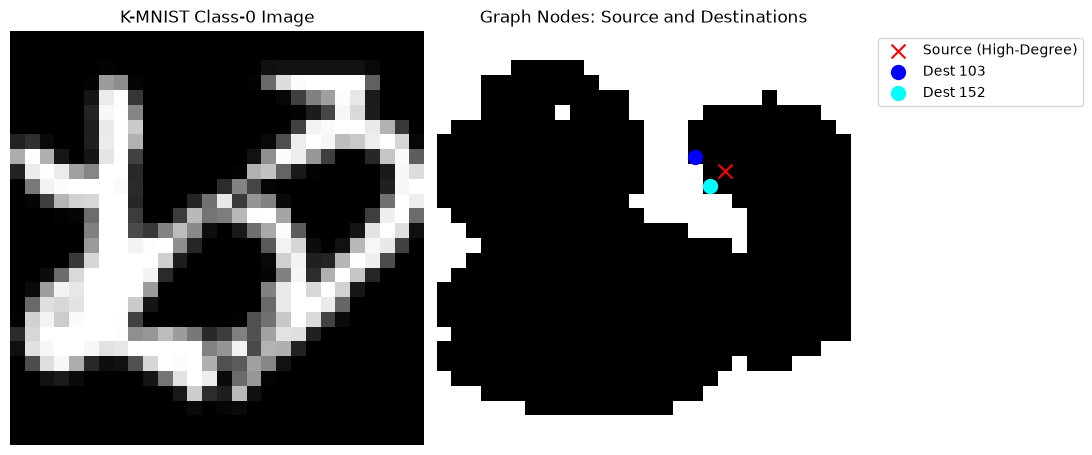

In [14]:
# 1. Reconstruct active_indices for Class 0
X_train, y_train, _, _ = load_mnist(str(KMNIST_DIR), gz=False)
idx = np.where(y_train == 0)[0][:200]
images = X_train[idx].astype(np.float64) / 255.0
active_indices, T_rebuilt = build_class_topology(images)

# Verify the reconstruction matches the cached, already-verified T before trusting node positions below
with open(CONSTRUCTIONS_PATH, 'rb') as f:
    _constructions_check = pickle.load(f)[0]
T_cached = _constructions_check['constructions']['T']
assert np.allclose(T_rebuilt, T_cached), 'Rebuilt T does not match cached T -- node positions below would be wrong'
print(f'Verified: rebuilt T matches cached T (max abs diff = {np.max(np.abs(T_rebuilt - T_cached)):.2e})')

# 2. Map node indices to grid coordinates
def to_coords(node_idx):
    grid_idx = active_indices[node_idx]
    return divmod(grid_idx, 28)

stim_coords = to_coords(node_lookup['high'])
dest1_coords = to_coords(103)
dest2_coords = to_coords(152)

# 3. Plot the source K-MNIST image alongside the graph-node map
grid = np.zeros((28, 28))
grid.flat[active_indices] = 1

fig, (ax_image, ax_nodes) = plt.subplots(1, 2, figsize=(11, 5))
ax_image.imshow(images[0], cmap='gray', origin='upper', vmin=0, vmax=1)
ax_image.set_title('K-MNIST Class-0 Image')
ax_image.axis('off')

ax_nodes.imshow(grid, cmap='Greys', origin='upper')
ax_nodes.scatter(stim_coords[1], stim_coords[0], color='red', marker='x', s=100, label='Source (High-Degree)')
ax_nodes.scatter(dest1_coords[1], dest1_coords[0], color='blue', marker='o', s=100, label='Dest 103')
ax_nodes.scatter(dest2_coords[1], dest2_coords[0], color='cyan', marker='o', s=100, label='Dest 152')
ax_nodes.set_title('Graph Nodes: Source and Destinations')
ax_nodes.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax_nodes.axis('off')
fig.tight_layout()
plt.show()

## 7. Tangent vs. Residual: Linear Routing

Finally, we compare the concentration across three components of the response:
1. **Finite**: The total response.
2. **Tangent**: The first-order linear approximation.
3. **Residual**: The nonlinear part (Finite - Tangent).

The analysis reveals that the concentration and destination patterns are almost entirely captured by the **tangent** response. This indicates that the observed concentration is a feature of first-order linear routing through the learned topology, rather than nonlinear attractor switching.


In [13]:
with open(RESULTS_PATH, "rb") as f:
    results = pickle.load(f)

cell_results = {k: v for k, v in results.items() if k[0] == 0 and k[2] == 'high'}

lin_summary = []
for field, label in [("fixed_time_q_tangent", "Tangent"), 
                      ("fixed_time_q", "Finite"), 
                      ("fixed_time_q_residual", "Residual")]:
    
    for (t_p, replica, node_label, sign, amp), trial in cell_results.items():
        q = trial[field]
        if q is None: continue
        argmax_node = np.argmax(q)
        top1 = q[argmax_node]
        lin_summary.append({'Component': label, 'sign': sign, 'amplitude': amp, 'top1': top1, 'argmax': argmax_node})

lin_df = pd.DataFrame(lin_summary)
pivot_top1 = lin_df.groupby(['Component', 'sign', 'amplitude'])['top1'].mean().unstack(level=0)
pivot_top1


Component         Finite  Residual   Tangent
sign amplitude                              
-1   0.025      0.638441  0.958453  0.665574
     0.200      0.412428  0.959304  0.665574
     0.800      0.184383  0.960162  0.665574
 1   0.025      0.691251  0.958149  0.665574
     0.200      0.831734  0.956822  0.665574
     0.800      0.975900  0.945969  0.665574

## Intermediate Snapshots and Animation

The cached results in `stage1b2_results.pkl` contain only the `event_aligned` and `fixed_time` (tau=T=2.5) snapshots of the energy distribution. Intermediate timepoints were not retained in the frozen cache to save space. Consequently, creating an animation of the energy distribution evolving over time would require re-running the full simulations, which is beyond the scope of this self-contained analysis artifact.
